# Red and White Wine
Is white wine more acidic due to fermentation without skins?
Hypothesis testing example: Difference of means

![Wine Hypothesis Image](Wine_Hypothesis.png)

In [1]:
import numpy as np
from datascience import *
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
file = 'winequality_redwhite.csv'

In [3]:
wine = Table.read_table(file)
wine

fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
7,0.27,0.36,20.7,0.045,45,170,1.001,3,0.45,8.8,6,white
6.3,0.3,0.34,1.6,0.049,14,132,0.994,3.3,0.49,9.5,6,white
8.1,0.28,0.4,6.9,0.05,30,97,0.9951,3.26,0.44,10.1,6,white
7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.4,9.9,6,white
7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.4,9.9,6,white
8.1,0.28,0.4,6.9,0.05,30,97,0.9951,3.26,0.44,10.1,6,white
6.2,0.32,0.16,7,0.045,30,136,0.9949,3.18,0.47,9.6,6,white
7,0.27,0.36,20.7,0.045,45,170,1.001,3,0.45,8.8,6,white
6.3,0.3,0.34,1.6,0.049,14,132,0.994,3.3,0.49,9.5,6,white
8.1,0.22,0.43,1.5,0.044,28,129,0.9938,3.22,0.45,11,6,white


In [4]:
wine.group('type')

type,count
red,1599
white,4898


## Hypothesis
White wines are more acidic than red

*Why*: White wines are usually fermented without skins, emphasizing acidity, while red wines are fermented with skins and seeds, imparting tannins that can mask the perception of acidity. 
[Lodi Growers](https://lodigrowers.com/everything-you-need-to-know-about-the-acidity-in-lodis-varietals/#:~:text=I'm%20also%20sharing%20this,Photo%20by:%20Getty%20Images.) 


### Null hypothesis
Difference in pH between individaul red and white wines is random

In [5]:
wine_group = wine.group('type',np.mean)
wine_group

type,fixed acidity mean,volatile acidity mean,citric acid mean,residual sugar mean,chlorides mean,free sulfur dioxide mean,total sulfur dioxide mean,density mean,pH mean,sulphates mean,alcohol mean,quality mean
red,8.31964,0.527821,0.270976,2.53881,0.0874665,15.8749,46.4678,0.996747,3.31111,0.658149,10.423,5.63602
white,6.85479,0.278241,0.334192,6.39141,0.0457724,35.3081,138.361,0.994027,3.18827,0.489847,10.5143,5.87791


## Difference of means
use index [1] and [0] to access elements of array created from column

In [6]:
pHdiff = wine_group.column('pH mean')[1] - wine_group.column('pH mean')[0]
pHdiff

-0.12284655630267016

White has lower pH which means more acidic

## Simulate Null Distribution

In [7]:
pHdiff_sim = []

for i in np.arange(300):
    wine_group_s = wine.sample().group('type',np.mean)
    sim_diff = wine_group_s.column('pH mean')[1] - wine_group_s.column('pH mean')[0]
    pHdiff_sim.append(sim_diff)


In [8]:
len(pHdiff_sim)

300

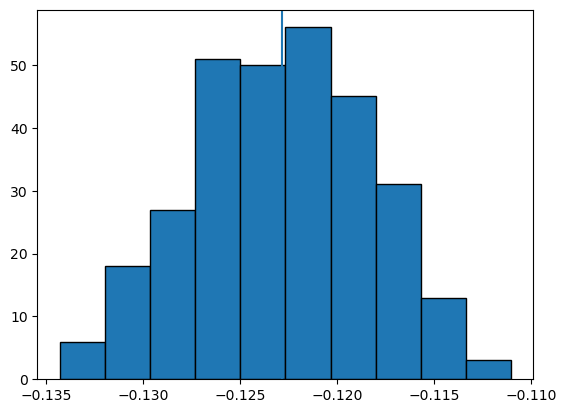

In [9]:
plt.hist(pHdiff_sim)
plt.axvline(pHdiff)

In [10]:
p = np.count_nonzero( np.array(pHdiff_sim) >= 0 )/len(pHdiff_sim)
p

0.0

#### p < 0.05 Data suports Hypothesis, discard Null hypothesis

## Alternate Simulation of Null Distribution

In [11]:
pHdiff_sim = []
winetype = wine.column('type')

for i in np.arange(300):
    winetype_s = np.random.shuffle(winetype)
    wine_s = wine.with_column('Stype',winetype_s)    
    wine_group_s = wine_s.group('type',np.mean)
    sim_diff = wine_group_s.column('pH mean')[1] - wine_group_s.column('pH mean')[0]
    pHdiff_sim.append(sim_diff)


(array([  2.,   5.,   9.,  17.,  45.,  68.,  66.,  49.,  25.,  14.]),
 array([-0.01543567, -0.01281095, -0.01018624, -0.00756152, -0.00493681,
        -0.00231209,  0.00031262,  0.00293734,  0.00556205,  0.00818677,
         0.01081148]),
 <BarContainer object of 10 artists>)

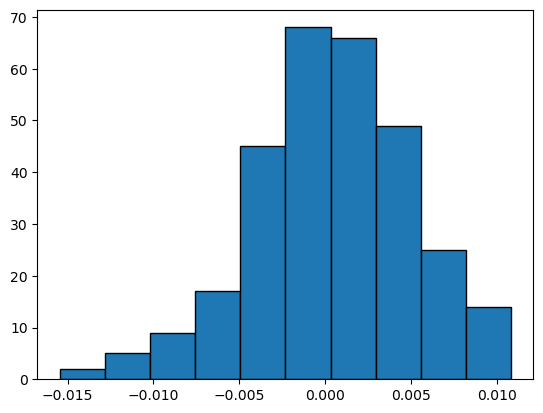

In [12]:
plt.hist(pHdiff_sim)

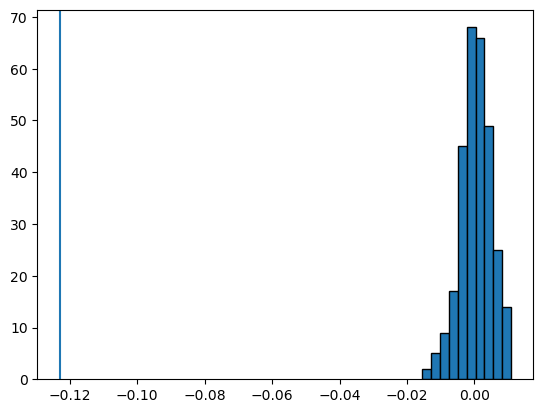

In [13]:
plt.hist(pHdiff_sim)
plt.axvline(pHdiff)

In [14]:
p = np.count_nonzero( pHdiff_sim <= pHdiff )/len(pHdiff_sim)
p

0.0

#### p < 0.05 Data suports Hypothesis, discard Null hypothesis